# GEARS — Comparaison avec des exemples de simulation CHARME

Charge une série temporelle externe (ex. `CHARME.csv`) et la compare aux profils de charge reconstruits par GEARS.

**Usage :** adapter les constantes dans la cellule de configuration, puis exécuter toutes les cellules (`Kernel › Restart & Run All`).

## 1. Configuration

In [ ]:
# === CONFIGURATION — modifier selon ton usage ===
EXTERNAL_FILE  = "CharMEMT_SimMT_CharME20182025_NbV20182025_03032026.csv"      # chemin vers la simulation externe (relatif à ce notebook)
YEAR           = 2025            # année à analyser
N_DAYS_MC      = 10              # jours Monte-Carlo pour stabiliser les profils GEARS
CHARGING_MODE  = "fixed_power"   # "mean_power" | "fixed_power" | "by_location"
FIXED_POWER_KW = 7.4             # utilisé uniquement si CHARGING_MODE == "fixed_power"
RESOLUTION_MIN = 60              # résolution temporelle pour le smart charging (minutes)
SCALE_TO_MATCH = True            # rescaler GEARS à la médiane de la série externe

# Palette commune (externe / GEARS)
COLOR_EXT   = "#2563EB"  # bleu
COLOR_GEARS = "#F97316"  # orange


In [50]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde

from gears import NativeGMMRegistry, LOCATION_POWER_PRESETS
from gears.output.aggregator import OutputAggregator
from gears.data.schemas import _season

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Noms courts des jours de la semaine (0 = Lundi)
JOURS = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
SAISONS = ["Hiver", "Printemps", "Été", "Automne"]
SAISON_MAP = {"winter": "Hiver", "spring": "Printemps", "summer": "Été", "autumn": "Automne"}


## 2. Chargement de la simulation externe

Lecture robuste de `CHARME.csv` : séparateur `;`, virgule décimale, colonne `Instant` UTC. On filtre sur `YEAR` et on renomme en colonnes standards.

In [51]:
# Lecture du fichier externe
csv_path = Path(EXTERNAL_FILE)
if not csv_path.is_absolute():
    csv_path = Path(__file__).parent / csv_path if '__file__' in dir() else Path(csv_path)

df_ext_raw = pd.read_csv(
    csv_path,
    sep=';',
    decimal=',',
    parse_dates=['Instant'],
)

# Supprimer le fuseau horaire UTC pour simplifier les comparaisons
df_ext_raw['Instant'] = df_ext_raw['Instant'].dt.tz_localize(None)

# Filtrer sur l'année cible et renommer
df_ext = (
    df_ext_raw[df_ext_raw['Instant'].dt.year == YEAR]
    .rename(columns={'Instant': 'time', 'P_MW': 'power_mw'})
    .set_index('time')
    [['power_mw']]
    .copy()
)

# Ajouter des colonnes calendaires utiles pour les analyses
df_ext['hour']        = df_ext.index.hour
df_ext['dayofweek']   = df_ext.index.dayofweek  # 0=Lundi
df_ext['jour']        = df_ext['dayofweek'].map(lambda d: JOURS[d])
df_ext['is_weekend']  = df_ext['dayofweek'] >= 5
df_ext['month']       = df_ext.index.month
df_ext['saison']      = df_ext['month'].map(_season).map(SAISON_MAP)
df_ext['type_jour']   = df_ext['is_weekend'].map({False: 'Semaine', True: 'Week-end'})

print(f"Série externe : {len(df_ext)} heures ({YEAR})")
print(f"  Plage      : {df_ext.index.min()} → {df_ext.index.max()}")
print(f"  Moyenne    : {df_ext['power_mw'].mean():.1f} MW")
print(f"  Médiane    : {df_ext['power_mw'].median():.1f} MW")
print(f"  Max        : {df_ext['power_mw'].max():.1f} MW")


Série externe : 8760 heures (2025)
  Plage      : 2025-01-01 00:00:00 → 2025-12-31 23:00:00
  Moyenne    : 605.4 MW
  Médiane    : 587.6 MW
  Max        : 2536.3 MW


## 3. Chargement du GMM et reconstruction des profils GEARS

On charge le bundle `"french"` depuis `NativeGMMRegistry`, puis on reconstruit un profil horaire annuel via `OutputAggregator.build_load_profiles()`.

In [52]:
registry = NativeGMMRegistry()
gmm = registry.load("french")
agg = OutputAggregator(resolution_min=RESOLUTION_MIN)

print(f"GMM chargé : {len(gmm.models_)} strates "
      f"({', '.join(gmm.stratify_by)})")


GMM chargé : 8008 strates (location_type, department, day_of_week, season)


In [53]:
result = agg.build_load_profiles(
    gmm=gmm,
    year=YEAR,
    n_days_mc=N_DAYS_MC,
    charging_mode=CHARGING_MODE,
    charger_power_kw=FIXED_POWER_KW,   # ignoré si mode != 'fixed_power'
)

g_ts = result['ts'].copy()  # pd.Series horaire en MW

print(f"Profils GEARS construits : mode={result['charging_mode']}")
print(f"  Moyenne brute : {g_ts.mean():.3f} MW")
print(f"  Médiane brute : {g_ts.median():.3f} MW")
print(f"  Max brut      : {g_ts.max():.3f} MW")


Profils GEARS construits : mode=fixed_power
  Moyenne brute : 2.645 MW
  Médiane brute : 1.886 MW
  Max brut      : 6.843 MW


In [54]:
# ── Rescaling optionnel (médiane-à-médiane) ──────────────────────────────
if SCALE_TO_MATCH:
    ext_median   = df_ext['power_mw'].median()
    gears_median = g_ts.median()
    scale_factor = ext_median / gears_median
    g_ts = g_ts * scale_factor
    print(f"Rescaling activé : ×{scale_factor:.4f} "
          f"(médiane externe={ext_median:.1f} MW, GEARS brut={gears_median:.3f} MW)")
else:
    scale_factor = 1.0
    print("Rescaling désactivé — les deux séries sont comparées telles quelles.")

# Aligner les indices : on garde l'intersection des timestamps
g_ts.index = pd.date_range(f"{YEAR}-01-01", periods=len(g_ts), freq='h')
common_idx  = df_ext.index.intersection(g_ts.index)
ext_aligned = df_ext.loc[common_idx, 'power_mw']
g_aligned   = g_ts.loc[common_idx]

# Colonnes calendaires sur la série GEARS alignée
g_df = g_aligned.rename('power_mw').to_frame()
g_df['hour']      = g_df.index.hour
g_df['dayofweek'] = g_df.index.dayofweek
g_df['jour']      = g_df['dayofweek'].map(lambda d: JOURS[d])
g_df['is_weekend']= g_df['dayofweek'] >= 5
g_df['month']     = g_df.index.month
g_df['saison']    = g_df['month'].map(_season).map(SAISON_MAP)
g_df['type_jour'] = g_df['is_weekend'].map({False: 'Semaine', True: 'Week-end'})

print(f"\nPoints communs : {len(common_idx)} heures")


Rescaling activé : ×311.5137 (médiane externe=587.6 MW, GEARS brut=1.886 MW)

Points communs : 8760 heures


## 4. Smart charging (optionnel)

Décommenter le bloc ci-dessous pour activer l'optimisation V1G. Un signal prix synthétique est fourni à titre d'exemple — remplacer par un vrai signal (ex. prix SPOT horaire EPEX) pour des résultats réalistes.

In [55]:
# ── Décommenter pour activer le smart charging ───────────────────────────
# import pandas as pd, numpy as np
#
# # Signal prix synthétique : sinusoïde journalière + bruit (€/kWh)
# # Creux la nuit (3h), pic en soirée (19h) — EXEMPLE UNIQUEMENT
# price_idx = pd.date_range(f"{YEAR}-01-01", periods=8760, freq='h')
# hours      = np.arange(8760) % 24
# price_signal = pd.Series(
#     0.12 + 0.04 * np.sin(2 * np.pi * (hours - 3) / 24)
#     + np.random.default_rng(42).normal(0, 0.005, 8760),
#     index=price_idx,
#     name='price_eur_per_kwh',
# )
#
# result_smart = agg.build_load_profiles(
#     gmm=gmm,
#     year=YEAR,
#     n_days_mc=N_DAYS_MC,
#     charging_mode=CHARGING_MODE,
#     charger_power_kw=FIXED_POWER_KW,
#     smart_charging_signal=price_signal,
# )
# g_ts_smart = result_smart['ts_smart'] * scale_factor  # même rescaling
# print(f"Série smart-charging construite : "
#       f"moyenne={g_ts_smart.mean():.3f} MW, max={g_ts_smart.max():.3f} MW")

# Indicateur pour les cellules suivantes
g_ts_smart = None  # mettre à jour si le bloc ci-dessus est exécuté


## 5. Série temporelle annuelle

Vue d'ensemble sur toute l'année — lissage hebdomadaire pour lisibilité.

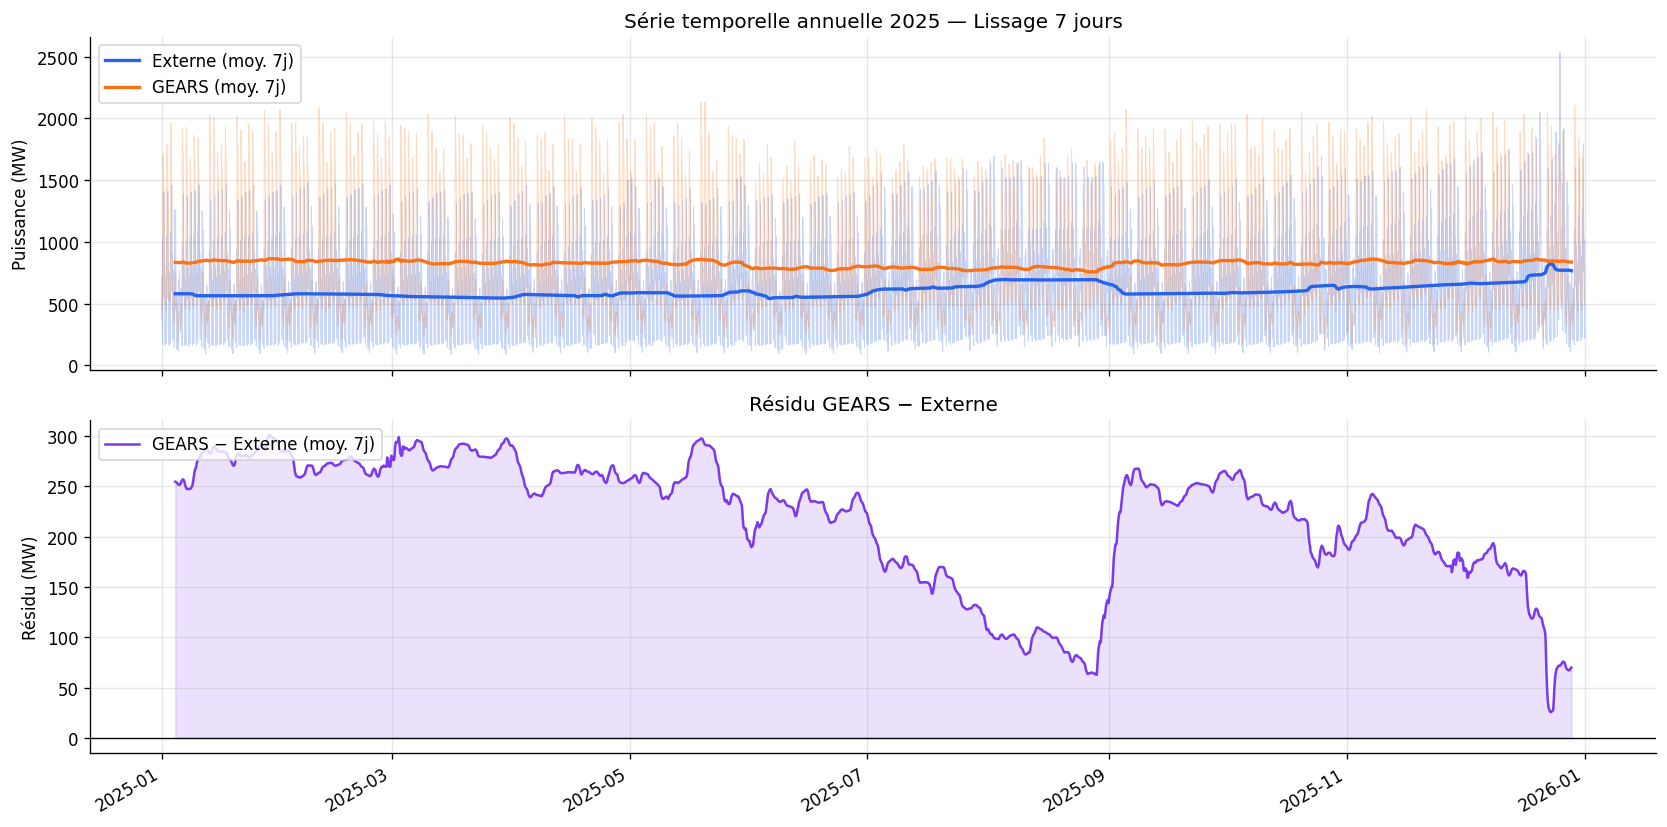

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Données brutes (transparentes)
axes[0].plot(ext_aligned.index, ext_aligned.values,
             color=COLOR_EXT, alpha=0.25, lw=0.6, label='_nolegend_')
axes[0].plot(g_aligned.index, g_aligned.values,
             color=COLOR_GEARS, alpha=0.25, lw=0.6, label='_nolegend_')
# Lissage 7 jours
axes[0].plot(ext_aligned.rolling(168, center=True).mean(),
             color=COLOR_EXT, lw=2, label='Externe (moy. 7j)')
axes[0].plot(g_aligned.rolling(168, center=True).mean(),
             color=COLOR_GEARS, lw=2, label='GEARS (moy. 7j)')
axes[0].set_ylabel('Puissance (MW)')
axes[0].set_title(f'Série temporelle annuelle {YEAR} — Lissage 7 jours')
axes[0].legend(loc='upper left')

# Résidu (différence)
residual = g_aligned.values - ext_aligned.values
axes[1].axhline(0, color='black', lw=0.8)
axes[1].plot(ext_aligned.index, pd.Series(residual, index=ext_aligned.index)
             .rolling(168, center=True).mean(),
             color='#7C3AED', lw=1.5, label='GEARS − Externe (moy. 7j)')
axes[1].fill_between(ext_aligned.index,
                     pd.Series(residual, index=ext_aligned.index)
                     .rolling(168, center=True).mean(),
                     0, alpha=0.15, color='#7C3AED')
axes[1].set_ylabel('Résidu (MW)')
axes[1].set_title('Résidu GEARS − Externe')
axes[1].legend(loc='upper left')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 6. Distribution de la puissance — densité globale (KDE)

Comparaison de la forme des distributions sur l'ensemble de l'année.

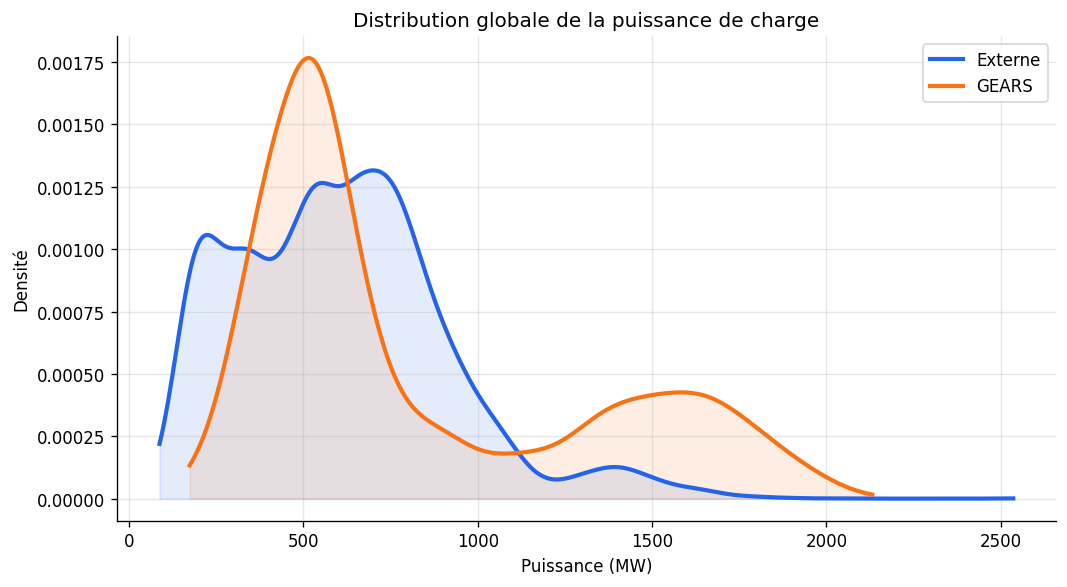

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))

for vals, label, color in [
    (ext_aligned.values, 'Externe', COLOR_EXT),
    (g_aligned.values,   'GEARS',   COLOR_GEARS),
]:
    kde = gaussian_kde(vals, bw_method='scott')
    x   = np.linspace(vals.min(), vals.max(), 400)
    ax.plot(x, kde(x), color=color, lw=2.5, label=label)
    ax.fill_between(x, kde(x), alpha=0.12, color=color)

ax.set_xlabel('Puissance (MW)')
ax.set_ylabel('Densité')
ax.set_title('Distribution globale de la puissance de charge')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Distribution par type de jour — Semaine vs Week-end

Vérification que GEARS reproduit correctement le contraste de comportement entre jours ouvrés et week-end.

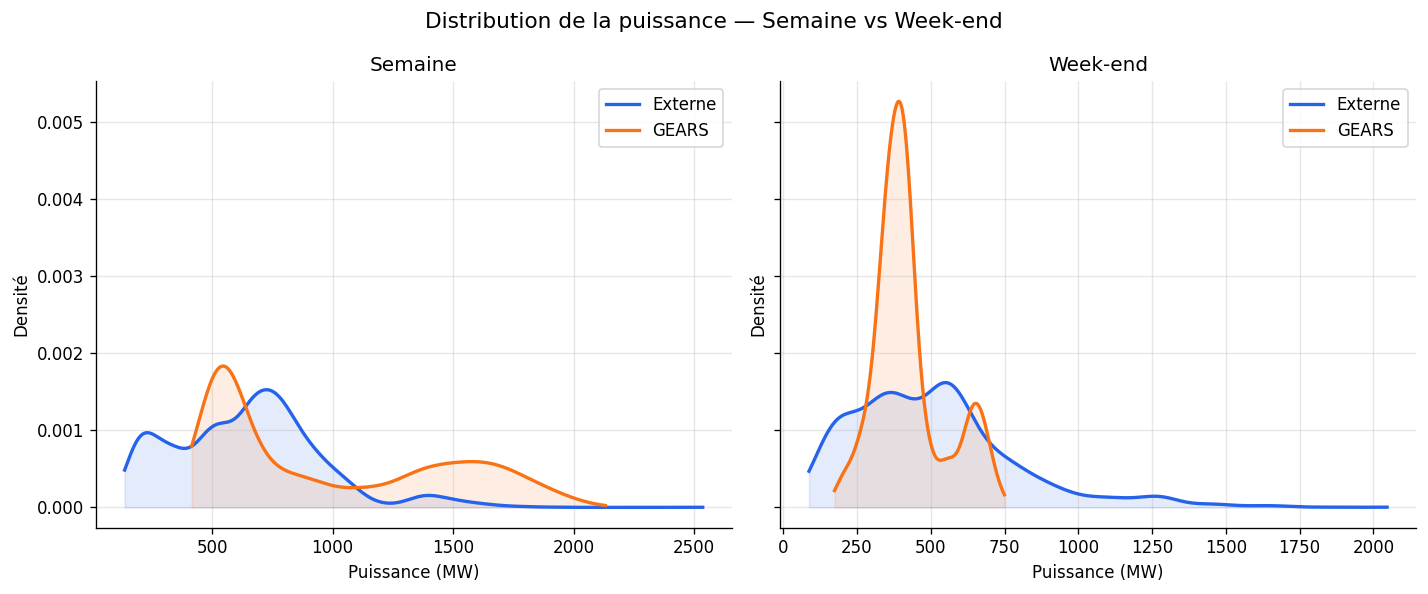

In [58]:
type_jours = ['Semaine', 'Week-end']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, tj in zip(axes, type_jours):
    for df_src, label, color in [
        (df_ext,  'Externe', COLOR_EXT),
        (g_df,    'GEARS',   COLOR_GEARS),
    ]:
        vals = df_src.loc[df_src['type_jour'] == tj, 'power_mw'].values
        if len(vals) < 10:
            continue
        kde = gaussian_kde(vals, bw_method='scott')
        x   = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(x, kde(x), color=color, lw=2, label=label)
        ax.fill_between(x, kde(x), alpha=0.12, color=color)
    ax.set_title(tj)
    ax.set_xlabel('Puissance (MW)')
    ax.set_ylabel('Densité')
    ax.legend()

fig.suptitle('Distribution de la puissance — Semaine vs Week-end', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Distribution par saison

Identification des biais saisonniers éventuels.

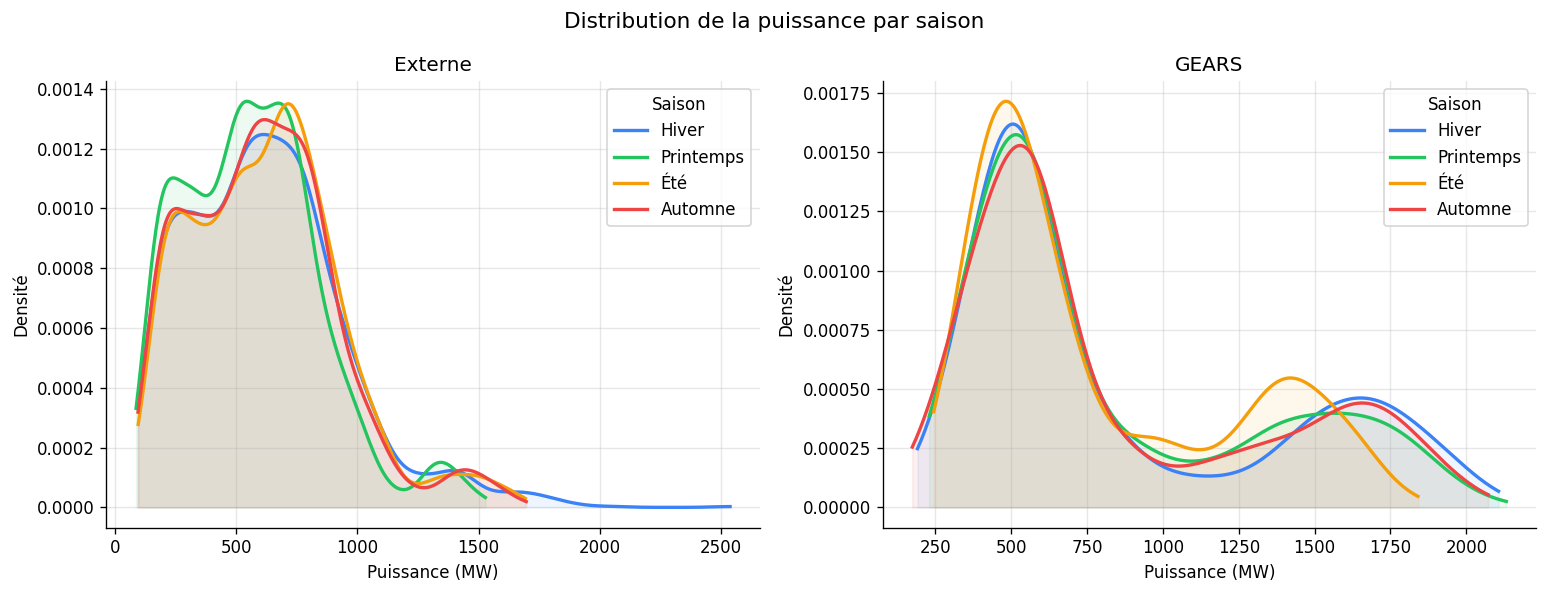

In [59]:
saisons_ord = ['Hiver', 'Printemps', 'Été', 'Automne']
palette_s   = ['#3B82F6', '#22C55E', '#F59E0B', '#EF4444']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (df_src, label) in zip(
    axes,
    [(df_ext, 'Externe'), (g_df, 'GEARS')],
):
    for saison, color in zip(saisons_ord, palette_s):
        vals = df_src.loc[df_src['saison'] == saison, 'power_mw'].values
        if len(vals) < 10:
            continue
        kde = gaussian_kde(vals, bw_method='scott')
        x   = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(x, kde(x), color=color, lw=2, label=saison)
        ax.fill_between(x, kde(x), alpha=0.08, color=color)
    ax.set_title(label)
    ax.set_xlabel('Puissance (MW)')
    ax.set_ylabel('Densité')
    ax.legend(title='Saison')

fig.suptitle('Distribution de la puissance par saison', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Profil horaire moyen par jour de la semaine

7 courbes (Lun–Dim) superposées — externe à gauche, GEARS à droite. Permet de vérifier la forme intra-journalière et les pics.

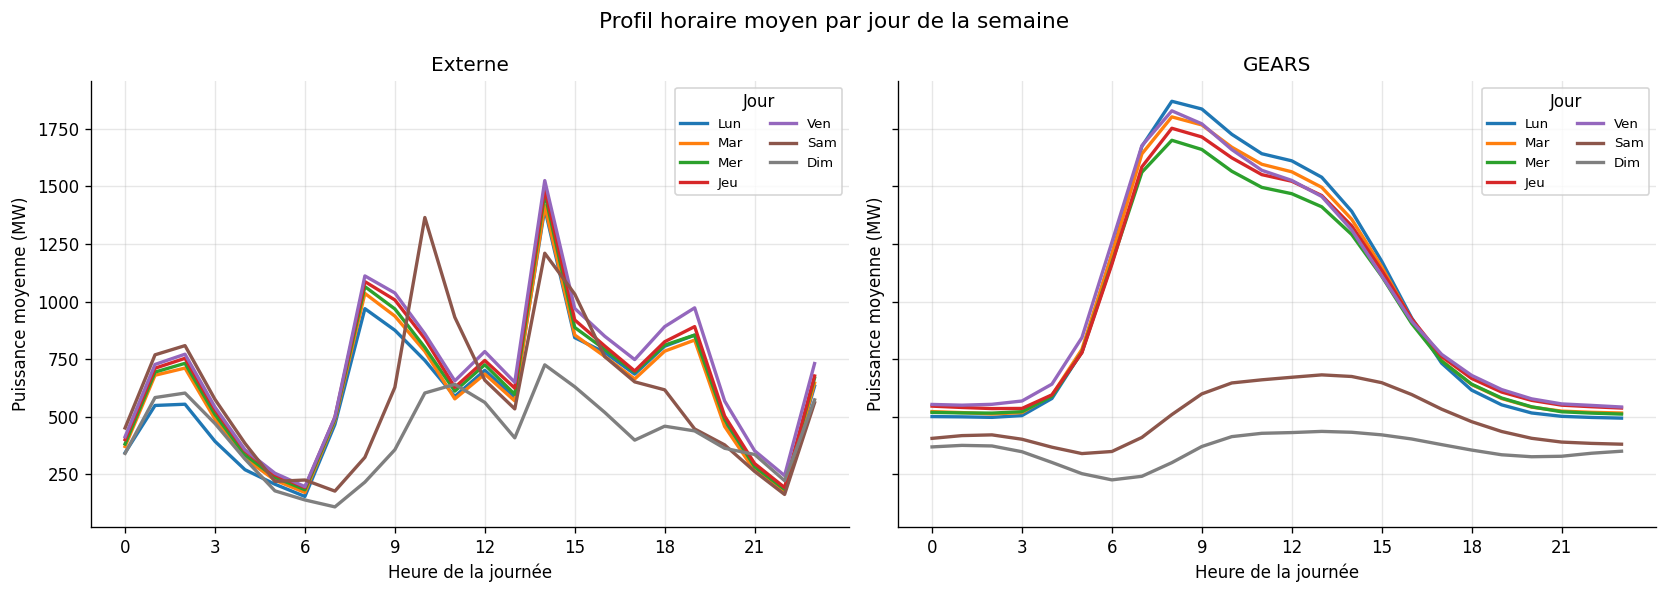

In [60]:
palette_dow = plt.cm.tab10(np.linspace(0, 0.7, 7))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (df_src, label) in zip(
    axes,
    [(df_ext, 'Externe'), (g_df, 'GEARS')],
):
    for dow_i, (jour, color) in enumerate(zip(JOURS, palette_dow)):
        mask   = df_src['dayofweek'] == dow_i
        profil = df_src.loc[mask].groupby('hour')['power_mw'].mean()
        ax.plot(profil.index, profil.values, color=color, lw=2, label=jour)
    ax.set_xlabel('Heure de la journée')
    ax.set_ylabel('Puissance moyenne (MW)')
    ax.set_title(label)
    ax.set_xticks(range(0, 24, 3))
    ax.legend(title='Jour', ncol=2, fontsize=8)

fig.suptitle('Profil horaire moyen par jour de la semaine', fontsize=13)
plt.tight_layout()
plt.show()


## 10. Profil horaire moyen par saison

4 courbes — externe à gauche, GEARS à droite.

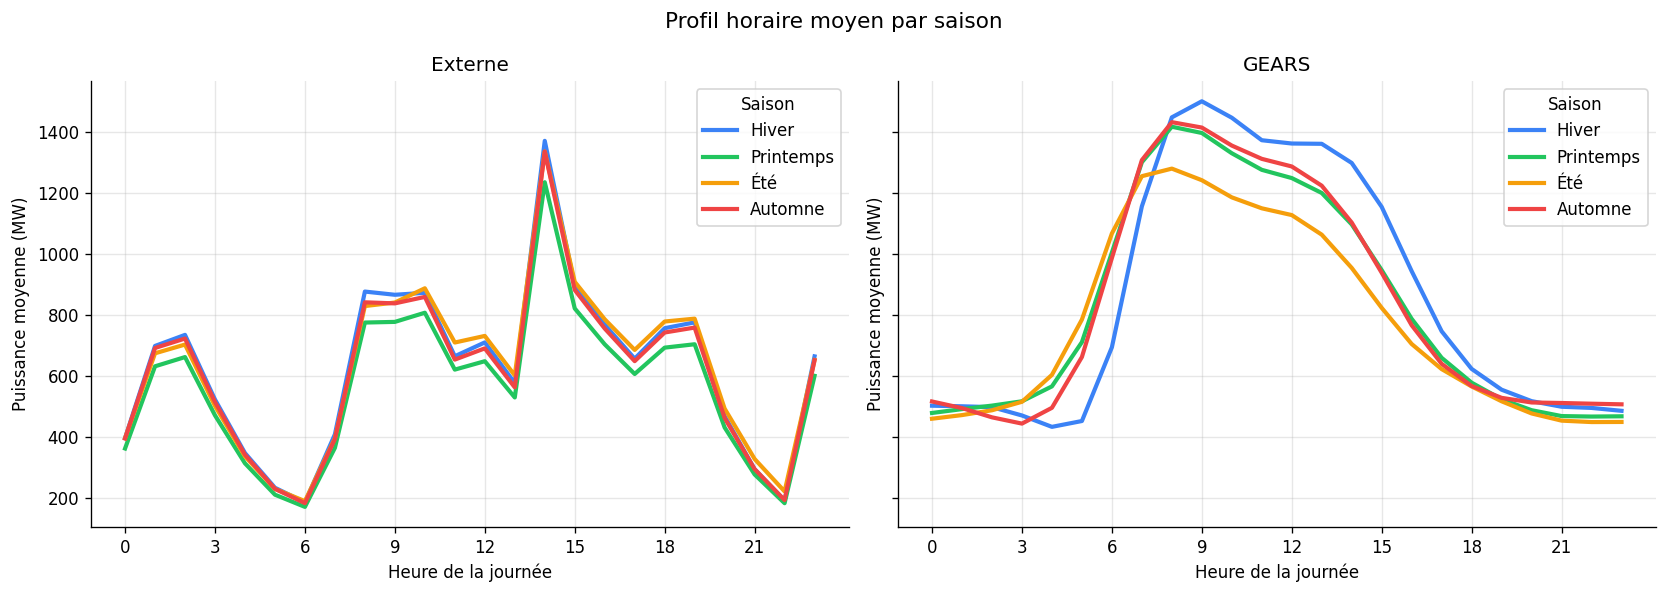

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (df_src, label) in zip(
    axes,
    [(df_ext, 'Externe'), (g_df, 'GEARS')],
):
    for saison, color in zip(saisons_ord, palette_s):
        mask   = df_src['saison'] == saison
        profil = df_src.loc[mask].groupby('hour')['power_mw'].mean()
        ax.plot(profil.index, profil.values, color=color, lw=2.5, label=saison)
    ax.set_xlabel('Heure de la journée')
    ax.set_ylabel('Puissance moyenne (MW)')
    ax.set_title(label)
    ax.set_xticks(range(0, 24, 3))
    ax.legend(title='Saison')

fig.suptitle('Profil horaire moyen par saison', fontsize=13)
plt.tight_layout()
plt.show()


## 11. Énergie moyenne par jour de la semaine

Barplot comparatif — une barre par source et par jour. L'énergie journalière est la somme des puissances horaires (MW·h ≈ MWh).

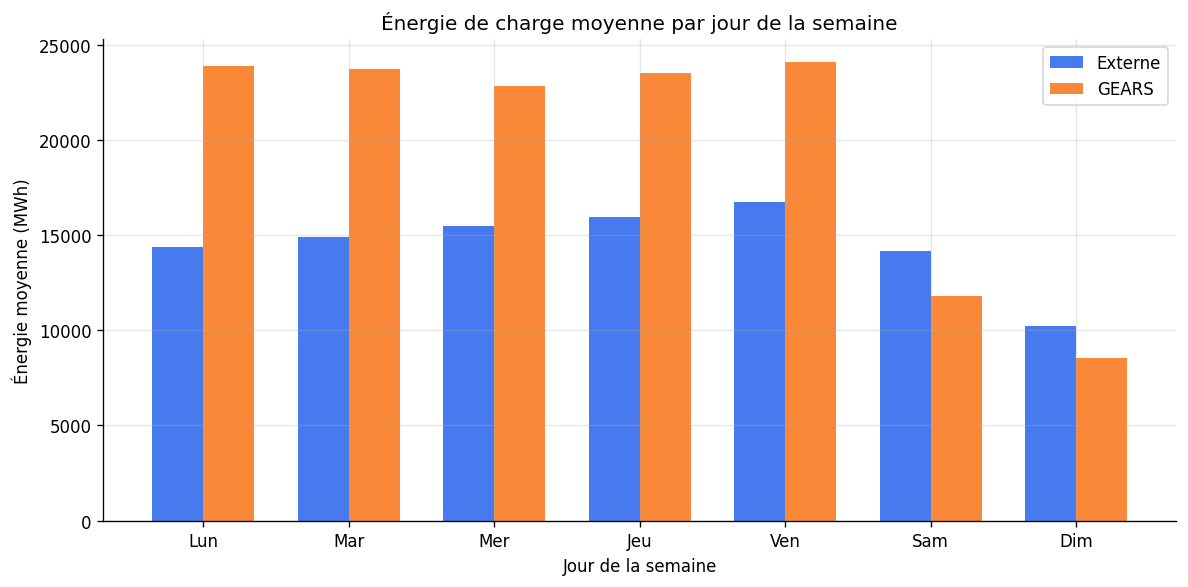

In [62]:
# Calculer l'énergie journalière (somme des MW sur 24h = MWh)
def energie_par_dow(df_src):
    daily = (
        df_src.assign(date=df_src.index.normalize())
        .groupby(['date', 'dayofweek'])['power_mw'].sum()
        .reset_index()
    )
    return daily.groupby('dayofweek')['power_mw'].mean()

eng_ext   = energie_par_dow(df_ext)
eng_gears  = energie_par_dow(g_df)

x   = np.arange(7)
w   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_ext  = ax.bar(x - w/2, eng_ext.values,   w, color=COLOR_EXT,   label='Externe', alpha=0.85)
bars_gear = ax.bar(x + w/2, eng_gears.values, w, color=COLOR_GEARS, label='GEARS',   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(JOURS)
ax.set_xlabel('Jour de la semaine')
ax.set_ylabel('Énergie moyenne (MWh)')
ax.set_title('Énergie de charge moyenne par jour de la semaine')
ax.legend()
plt.tight_layout()
plt.show()


## 12. Comparaison plug-and-charge vs smart charging (si activé)

Cette section n'est active que si `g_ts_smart` a été calculé à l'étape 4. Elle compare les profils horaires sur une semaine représentative.

In [63]:
if g_ts_smart is not None:
    # Semaine représentative : première semaine complète de mars
    week_start = pd.Timestamp(f'{YEAR}-03-03')  # lundi
    week_end   = week_start + pd.Timedelta(days=6, hours=23)

    ts_plug_week  = g_aligned.loc[week_start:week_end]
    ts_smart_week = g_ts_smart.loc[week_start:week_end]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ts_plug_week.index, ts_plug_week.values,
            color=COLOR_GEARS, lw=2, label='GEARS — Plug-and-charge', alpha=0.8)
    ax.plot(ts_smart_week.index, ts_smart_week.values,
            color='#059669', lw=2, linestyle='--', label='GEARS — Smart charging (V1G)')
    ax.set_xlabel('Date / Heure')
    ax.set_ylabel('Puissance (MW)')
    ax.set_title('Profil de charge — Semaine du 3 mars (plug-and-charge vs smart charging)')
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print("Smart charging non activé. Décommenter la cellule 4 pour l'activer.")


Smart charging non activé. Décommenter la cellule 4 pour l'activer.


## 13. Métriques synthétiques

Tableau récapitulatif pour une comparaison rapide des deux sources.

In [64]:
def peak_hour(series):
    """Heure modale du pic journalier (médiane sur l'année)."""
    daily_peaks = (
        series.to_frame('mw')
        .assign(date=series.index.normalize(),
                hour=series.index.hour)
        .loc[series.to_frame('mw')
             .assign(date=series.index.normalize(),
                     hour=series.index.hour)
             .groupby('date')['mw'].transform('max')
             == series.to_frame('mw').assign(date=series.index.normalize())['mw']]
        ['hour']
    )
    return int(daily_peaks.mode()[0])

def energie_annuelle_twh(series):
    """Somme des MW horaires → TWh (MW·h / 1 000 000)."""
    return series.sum() / 1_000_000

metrics = {
    'Métrique': [
        'Moyenne (MW)',
        'Médiane (MW)',
        'Max (MW)',
        'Peak hour (heure)',
        'Énergie annuelle (TWh)',
    ],
    'Externe': [
        f"{ext_aligned.mean():.2f}",
        f"{ext_aligned.median():.2f}",
        f"{ext_aligned.max():.2f}",
        f"{peak_hour(ext_aligned):02d}h",
        f"{energie_annuelle_twh(ext_aligned):.4f}",
    ],
    'GEARS': [
        f"{g_aligned.mean():.2f}",
        f"{g_aligned.median():.2f}",
        f"{g_aligned.max():.2f}",
        f"{peak_hour(g_aligned):02d}h",
        f"{energie_annuelle_twh(g_aligned):.4f}",
    ],
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_string(index=False))

# Différences relatives
print("\n— Biais relatif GEARS vs Externe —")
for k, ext_v, g_v in zip(
    metrics['Métrique'][:3],
    [ext_aligned.mean(), ext_aligned.median(), ext_aligned.max()],
    [g_aligned.mean(),   g_aligned.median(),   g_aligned.max()],
):
    biais = (g_v - ext_v) / ext_v * 100
    print(f"  {k:<25s}: {biais:+.1f}%")


              Métrique Externe   GEARS
          Moyenne (MW)  605.39  823.99
          Médiane (MW)  587.65  587.65
              Max (MW) 2536.31 2131.70
     Peak hour (heure)     14h     08h
Énergie annuelle (TWh)  5.3032  7.2182

— Biais relatif GEARS vs Externe —
  Moyenne (MW)             : +36.1%
  Médiane (MW)             : +0.0%
  Max (MW)                 : -16.0%
